In [1]:
# Cell 0: Install Necessary Packages (Updated for Python 3.10/3.11 compatibility)

import subprocess
import sys
import logging


In [2]:
# # Configure logging
# logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# def install_package(package):
#     """Installs a package using pip and logs the output."""
#     logging.info(f"Attempting to install {package}...")
#     try:
#         process = subprocess.run([sys.executable, "-m", "pip", "install", package], 
#                                  capture_output=True, text=True, check=True)
#         logging.info(f"Successfully installed {package}:\n{process.stdout}")
#     except subprocess.CalledProcessError as e:
#         logging.error(f"Failed to install {package}:\n{e.stderr}")
#         print(f"Error installing {package}. Please check the logs above for details.")
#     except Exception as e:
#         logging.error(f"An unexpected error occurred during installation of {package}: {e}")
#         print(f"An unexpected error occurred during installation of {package}. See logs.")

# # List of packages to install
# # Removed specific numpy version constraint to allow compatibility with TensorFlow
# packages = [
#     "numpy",               # Let pip choose a compatible version
#     "opencv-python",
#     "tensorflow",
#     "matplotlib",
#     "sklearn"
#     "Pillow",              # For PIL.Image
#     "ipython",             # For IPython.display
#     "rasterio"             # For TIFF thermal image processing
# ]

# print("Starting package installation. This may take a few minutes...")

# for package in packages:
#     install_package(package)

# print("\nPackage installation process complete. Please check the logs for any errors.")
# print("If using Jupyter, you might need to restart the kernel after installation.")

# logging.info("Package installation script finished.")

Found 2003 paired image-mask samples.
Train dataset size: 1602 samples
Validation dataset size: 401 samples

Visualizing a few samples from the training dataset:


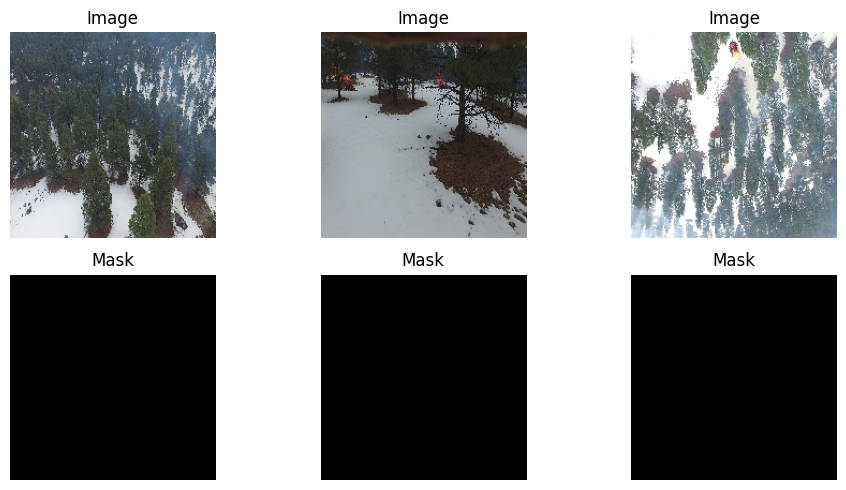


Data loading and preprocessing setup complete for segmentation model.


In [3]:
# Cell 1: Constants and Data Loading for Segmentation Model

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
import cv2
import glob
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt # Added for visualization

# Define paths and image dimensions
DATA_DIR = 'data'
IMAGES_DIR = os.path.join(DATA_DIR, 'images')
MASKS_DIR = os.path.join(DATA_DIR, 'Masks')

IMG_HEIGHT = 192  # Standard height for segmentation models
IMG_WIDTH = 192   # Standard width for segmentation models
IMG_CHANNELS = 3  # RGB images
MASK_CHANNELS = 1 # Grayscale masks (e.g., 0 for background, 255 for fire)
BATCH_SIZE = 8
BUFFER_SIZE = tf.data.AUTOTUNE # For dataset prefetching

# --- Helper Functions for Data Loading ---

def load_image(image_path):
    """Loads an RGB image (JPEG), resizes it, and normalizes pixel values."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=IMG_CHANNELS) # Changed to decode_jpeg
    image = tf.image.convert_image_dtype(image, tf.float32) # Normalize to [0, 1]
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    return image

def load_mask(mask_path):
    """Loads a grayscale mask (PNG), resizes it, and normalizes to [0, 1]."""
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=MASK_CHANNELS) # Masks are PNG
    mask = tf.image.convert_image_dtype(mask, tf.float32) # Normalize to [0, 1]
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    # Ensure mask is binary (0 or 1) if it originally contains 0 and 255 values
    mask = tf.where(mask > 0.5, 1.0, 0.0) # Threshold to make it strictly binary
    return mask

def preprocess_segmentation_data(image_path, mask_path):
    """Loads and preprocesses an image and its corresponding mask."""
    image = load_image(image_path)
    mask = load_mask(mask_path)
    return image, mask

def augment_data(image, mask):
    """Applies random augmentations to both image and mask."""
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)
    # Random rotation
    if tf.random.uniform(()) > 0.5:
        angle = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2) # Radians
        image = tf.image.rot90(image, k=tf.cast(tf.round(angle / (np.pi/2)), tf.int32))
        mask = tf.image.rot90(mask, k=tf.cast(tf.round(angle / (np.pi/2)), tf.int32))

    # Add small random brightness and contrast for images only
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    
    # Clip values to ensure they are still within [0, 1] after augmentations
    image = tf.clip_by_value(image, 0.0, 1.0)
    mask = tf.clip_by_value(mask, 0.0, 1.0) # Masks should remain binary
    
    return image, mask

def create_segmentation_dataset(image_paths, mask_paths, apply_augmentations=True, shuffle_seed=None):
    """
    Creates a tf.data.Dataset for segmentation, pairing images with masks,
    applying preprocessing and optional augmentations.
    """
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    
    if shuffle_seed is not None:
        dataset = dataset.shuffle(buffer_size=len(image_paths), seed=shuffle_seed)

    dataset = dataset.map(preprocess_segmentation_data, num_parallel_calls=tf.data.AUTOTUNE)
    if apply_augmentations:
        dataset = dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(BUFFER_SIZE)
    return dataset

# --- Collect Image and Mask Paths ---
print("Collecting image and mask paths...")
all_image_paths = sorted(glob.glob(os.path.join(IMAGES_DIR, 'image_*.jpg'))) # Updated pattern
all_mask_paths = sorted(glob.glob(os.path.join(MASKS_DIR, 'image_*.png'))) # Updated pattern

# Ensure paths exist
if not all_image_paths:
    print(f"No images found in {IMAGES_DIR}. Please check the directory and naming convention (image_*.jpg).")
if not all_mask_paths:
    print(f"No masks found in {MASKS_DIR}. Please check the directory and naming convention (image_*.png).")

# Pair images and masks based on their number (e.g., image_0.jpg -> image_0.png)
paired_data = []
for img_path in all_image_paths:
    img_filename = os.path.basename(img_path)
    # Extracts '0' from 'image_0.jpg' or 'image_123.jpg'
    img_number = img_filename.split('_')[1].split('.')[0] 
    
    mask_filename_expected = f"image_{img_number}.png" # Expected mask filename
    mask_path_expected = os.path.join(MASKS_DIR, mask_filename_expected)
    
    if os.path.exists(mask_path_expected):
        paired_data.append({'image': img_path, 'mask': mask_path_expected})
    else:
        print(f"Warning: No matching mask found for image: {img_path} (expected {mask_path_expected})")

if not paired_data:
    print("No paired image and mask data found. Exiting.")
else:
    print(f"Found {len(paired_data)} paired image-mask samples.")

    # Extract paths for splitting
    image_paths = [d['image'] for d in paired_data]
    mask_paths = [d['mask'] for d in paired_data]

    # Split data into training and validation sets
    # Using a fixed seed for reproducibility
    train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(
        image_paths, mask_paths, test_size=0.2, random_state=42
    )

    # Create TensorFlow Datasets
    train_dataset = create_segmentation_dataset(train_image_paths, train_mask_paths, apply_augmentations=True, shuffle_seed=123)
    val_dataset = create_segmentation_dataset(val_image_paths, val_mask_paths, apply_augmentations=False)

    print(f"Train dataset size: {len(train_image_paths)} samples")
    print(f"Validation dataset size: {len(val_image_paths)} samples")

    # Optional: Visualize a few samples from the dataset to confirm loading
    print("\nVisualizing a few samples from the training dataset:")
    plt.figure(figsize=(10, 5))
    for i, (image, mask) in enumerate(train_dataset.take(1)):
        for j in range(min(BATCH_SIZE, 3)): # Display up to 3 samples from the first batch
            plt.subplot(2, 3, j + 1)
            plt.imshow(image[j].numpy())
            plt.title("Image")
            plt.axis("off")

            plt.subplot(2, 3, j + 4)
            plt.imshow(mask[j].numpy().squeeze(), cmap='gray') # Squeeze for 2D mask
            plt.title("Mask")
            plt.axis("off")
        break # Only take one batch
    plt.tight_layout()
    plt.show()

print("\nData loading and preprocessing setup complete for segmentation model.")

In [4]:
# Cell 2: U-Net Model Definition for Segmentation

from tensorflow.keras import layers
from tensorflow.keras.models import Model

def conv_block(input_tensor, num_filters):
    """Standard Convolutional Block (Conv -> BatchNorm -> ReLU)"""
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(num_filters, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    return x

def encoder_block(input_tensor, num_filters):
    """Encoder Block (Conv Block -> Max Pooling) and returns skip connection"""
    x = conv_block(input_tensor, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p # x is the skip connection

def decoder_block(input_tensor, skip_connection, num_filters):
    """Decoder Block (UpSampling -> Concatenation -> Conv Block)"""
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(input_tensor)
    x = layers.concatenate([x, skip_connection])
    x = conv_block(x, num_filters)
    return x

def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=MASK_CHANNELS):
    """
    Builds a U-Net model for semantic segmentation.
    num_classes is 1 for binary segmentation (e.g., fire/no-fire).
    """
    inputs = keras.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)   # s1 is skip connection, p1 is pooled output
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bridge (Bottleneck)
    b = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    # Output layer
    # For binary segmentation (MASK_CHANNELS=1), use 'sigmoid' activation.
    # For multi-class segmentation (MASK_CHANNELS > 1), use 'softmax' activation.
    if num_classes == 1:
        outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid', padding='same')(d4)
    else:
        outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', padding='same')(d4)

    model = Model(inputs, outputs, name="U-Net")
    return model

print("U-Net model definition complete.")

# Initialize the model (you can do this in Cell 3 as well)
segmentation_model = build_unet()
segmentation_model.summary() # Uncomment to see the model summary

U-Net model definition complete.


Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 192, 192,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 192,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 192, 192,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 96,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 96,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 48, 48,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 24, 24,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:
# Cell 3: Training the Segmentation Model

# Define the segmentation model
segmentation_model = build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=MASK_CHANNELS)

# Optional: Generate and save model plot
try:
    tf.keras.utils.plot_model(
        segmentation_model,
        to_file='figures/unet_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        expand_nested=True,
        dpi=300 # Higher resolution
    )
    print("U-Net architecture diagram saved to figures/unet_architecture.png")
except ImportError:
    print("Install pydot and graphviz to plot the model architecture.")
    print("  pip install pydot graphviz")
    print("  (Also install Graphviz system-wide if not already done: https://graphviz.org/download/)")
except Exception as e:
    print(f"An error occurred while plotting the model: {e}")

# --- Define Loss Function and Metrics ---
# For binary segmentation (MASK_CHANNELS=1), BinaryCrossentropy is common.
# Dice Loss (or F-score) is also very popular for imbalance classes.
# Let's use BinaryCrossentropy and include IoU (Intersection over Union) as a metric.

loss_function = tf.keras.losses.BinaryCrossentropy() # For binary masks (0 or 1)

# IoU Metric
def mean_iou(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32) # Convert predictions to binary (0 or 1)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    iou = (intersection + 1e-7) / (union + 1e-7) # Add epsilon to avoid division by zero
    return tf.reduce_mean(iou)

metrics = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    mean_iou
]

# --- Compile the model ---
learning_rate = 1e-4
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

segmentation_model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)

# --- Callbacks ---
# Optional: Add callbacks for early stopping, model checkpointing, etc.
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'segmentation_unet_model.keras',  # Save in Keras native format
        save_best_only=True,
        monitor='val_mean_iou',
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_mean_iou',
        patience=10, # Number of epochs with no improvement after which training will be stopped.
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_mean_iou',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode='max',
        verbose=1
    )
]

# --- Train the model ---
EPOCHS = 10 # Adjust as needed (Initial was 50)

print(f"\nStarting training for {EPOCHS} epochs...")
history = segmentation_model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks
)

print("\nSegmentation model training complete.")

# Optional: Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Loss and Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mean_iou'], label='Train IoU')
plt.plot(history.history['val_mean_iou'], label='Val IoU')
plt.title('Mean IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
U-Net architecture diagram saved to figures/unet_architecture.png

Starting training for 10 epochs...
Epoch 1/10


In [ ]:
# Cell 4: Prediction and Visualization for Segmentation Model

print("Preparing for segmentation prediction and visualization...")

# Load the best model if it was saved by ModelCheckpoint
# If you didn't use ModelCheckpoint, use the 'segmentation_model' object directly from Cell 3
try:
    loaded_segmentation_model = keras.models.load_model(
        'segmentation_unet_model.keras',
        custom_objects={'mean_iou': mean_iou} # Need to provide custom objects if used in compilation
    )
    print("Loaded best model from 'segmentation_unet_model.keras'")
except Exception as e:
    print(f"Could not load saved model: {e}. Using the 'segmentation_model' object directly from training.")
    loaded_segmentation_model = segmentation_model # Fallback to the model object in memory

if loaded_segmentation_model is None:
    print("Error: Segmentation model not available for prediction. Please train the model first.")
else:
    # Select a random sample from the validation set for prediction
    if val_image_paths and val_mask_paths:
        sample_idx = random.randint(0, len(val_image_paths) - 1)
        sample_image_path = val_image_paths[sample_idx]
        sample_mask_path = val_mask_paths[sample_idx]

        print(f"\n--- Predicting for Sample Image ---")
        print(f"Image: {os.path.basename(sample_image_path)}")
        print(f"True Mask: {os.path.basename(sample_mask_path)}")

        # Preprocess the sample image for prediction
        input_image = load_image(sample_image_path)
        true_mask = load_mask(sample_mask_path) # Load true mask for comparison

        # Add batch dimension for prediction (model expects a batch)
        input_image_batch = tf.expand_dims(input_image, 0)

        # Make prediction
        predicted_mask_batch = loaded_segmentation_model.predict(input_image_batch)
        predicted_mask = predicted_mask_batch[0] # Get rid of the batch dimension

        # Convert prediction to binary mask (if using sigmoid output)
        predicted_mask_binary = tf.cast(predicted_mask > 0.5, tf.float32)

        # --- Visualization ---
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.imshow(input_image.numpy())
        plt.title("Original Image")
        plt.axis('off')

        # True Mask
        plt.subplot(1, 3, 2)
        plt.imshow(true_mask.numpy().squeeze(), cmap='gray')
        plt.title("True Mask")
        plt.axis('off')

        # Predicted Mask
        plt.subplot(1, 3, 3)
        plt.imshow(predicted_mask_binary.numpy().squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        # Optional: Overlay predicted mask on original image
        plt.figure(figsize=(8, 8))
        plt.imshow(input_image.numpy())
        # Create a transparent overlay for the mask
        colored_mask = plt.cm.jet(predicted_mask_binary.numpy().squeeze()) # Use 'jet' or 'hot' for color
        colored_mask[..., 3] = predicted_mask_binary.numpy().squeeze() * 0.5 # Apply transparency based on mask value
        plt.imshow(colored_mask)
        plt.title("Predicted Mask Overlay")
        plt.axis('off')
        plt.show()

    else:
        print("No validation data available to select a sample for prediction. Please check data loading.")

print("\nSegmentation prediction and visualization complete.")SS